In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import shap
import warnings
warnings.filterwarnings('ignore')

# Load data
import sys
sys.path.append('../src')
from eda_utils import load_data

df = load_data('../data/insurance_data.csv')
print("Data shape:", df.shape)

2026-05-26 18:21:08,737 - INFO - Data loaded successfully from ../data/insurance_data.csv, shape: (10000, 21)


Data shape: (10000, 21)


In [2]:
# Ensure TransactionDate is datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# Vehicle age (approximate using RegistrationYear if available)
if 'RegistrationYear' in df.columns:
    # Assume current year is 2015 (end of dataset)
    df['VehicleAge'] = 2015 - df['RegistrationYear']
else:
    df['VehicleAge'] = 0  # placeholder

# Policy year (optional)
df['PolicyYear'] = df['TransactionDate'].dt.year

print("New features added.")

New features added.


In [3]:
# Define feature columns (exclude identifiers and targets)
id_cols = ['CustomerID', 'TransactionDate']
target_sev = 'TotalClaims'
target_prob = 'Claimed'

# Numerical features
num_features = ['Age', 'AnnualIncome', 'RiskScore', 'CustomValueEstimate', 'VehicleAge']

# Categorical features
cat_features = ['Gender', 'Province', 'VehicleType', 'CoverType', 'AutoMake']

# Ensure all categorical columns exist; if some are missing, adjust
available_cat = [c for c in cat_features if c in df.columns]
available_num = [c for c in num_features if c in df.columns]

print("Numerical features:", available_num)
print("Categorical features:", available_cat)

Numerical features: ['Age', 'AnnualIncome', 'RiskScore', 'CustomValueEstimate', 'VehicleAge']
Categorical features: ['Gender', 'Province', 'VehicleType', 'CoverType', 'AutoMake']


In [4]:
# Copy data
df_model = df.copy()

# Label encode categoricals
le_dict = {}
for col in available_cat:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# Scale numericals
scaler = StandardScaler()
df_model[available_num] = scaler.fit_transform(df_model[available_num])

# Combine features into X
X = df_model[available_num + available_cat].copy()
y_sev = df_model[target_sev]   # for severity (keep zeros for probability)
y_prob = df_model[target_prob].astype(int)  # for classification

In [5]:
X_train, X_test, y_train_prob, y_test_prob = train_test_split(X, y_prob, test_size=0.2, random_state=42, stratify=y_prob)
print(f"Probability model train: {X_train.shape}, test: {X_test.shape}")

Probability model train: (8000, 10), test: (2000, 10)


In [6]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train_prob)
y_pred_prob = rf_clf.predict(X_test)
y_pred_proba = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test_prob, y_pred_prob):.4f}")
print(f"Precision: {precision_score(y_test_prob, y_pred_prob):.4f}")
print(f"Recall: {recall_score(y_test_prob, y_pred_prob):.4f}")
print(f"F1: {f1_score(y_test_prob, y_pred_prob):.4f}")
print(f"AUC: {roc_auc_score(y_test_prob, y_pred_proba):.4f}")

Random Forest Classifier Performance:
Accuracy: 0.8515
Precision: 0.5481
Recall: 0.1857
F1: 0.2774
AUC: 0.7408


In [7]:
# Subset data where claims > 0
sev_data = df_model[df_model[target_sev] > 0].copy()
X_sev = sev_data[available_num + available_cat]
y_sev = sev_data[target_sev]

X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(X_sev, y_sev, test_size=0.2, random_state=42)
print(f"Severity model train: {X_sev_train.shape}, test: {X_sev_test.shape}")

Severity model train: (1228, 10), test: (307, 10)


In [8]:
lr = LinearRegression()
lr.fit(X_sev_train, y_sev_train)
y_pred_lr = lr.predict(X_sev_test)
print("Linear Regression:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_sev_test, y_pred_lr)):.2f}")
print(f"R²: {r2_score(y_sev_test, y_pred_lr):.4f}")

Linear Regression:
RMSE: 5256.18
R²: 0.2189


In [9]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_sev_train, y_sev_train)
y_pred_rf = rf_reg.predict(X_sev_test)
print("Random Forest Regressor:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_sev_test, y_pred_rf)):.2f}")
print(f"R²: {r2_score(y_sev_test, y_pred_rf):.4f}")

Random Forest Regressor:
RMSE: 5371.00
R²: 0.1844


In [10]:
xgb_reg = XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse')
xgb_reg.fit(X_sev_train, y_sev_train)
y_pred_xgb = xgb_reg.predict(X_sev_test)
print("XGBoost Regressor:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_sev_test, y_pred_xgb)):.2f}")
print(f"R²: {r2_score(y_sev_test, y_pred_xgb):.4f}")

XGBoost Regressor:
RMSE: 5995.12
R²: -0.0162


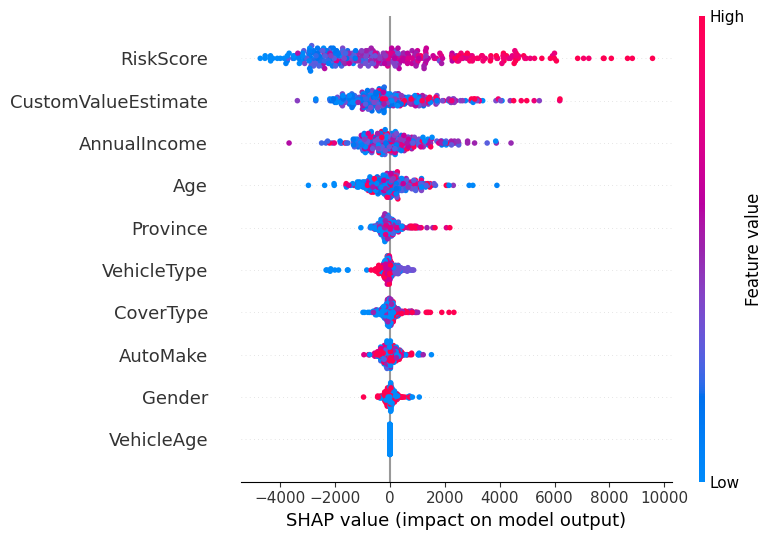

In [11]:
# SHAP requires the original feature names
explainer = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_sev_test)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sev_test, feature_names=available_num + available_cat, show=False)
plt.tight_layout()
plt.show()

## Model Performance Summary

### Claim Probability Model (Random Forest)

- **Training set:** 8000 rows, **Test set:** 2000 rows
- **Accuracy:** 0.8515
- **Precision:** 0.5481
- **Recall:** 0.1857
- **F1-score:** 0.2774
- **AUC:** 0.7408

**Interpretation:** The model correctly predicts 85% of cases overall, but it only identifies 19% of actual claims (low recall). This means the model is conservative – it tends to predict “no claim”. For business use, consider adjusting the classification threshold or using SMOTE to balance the classes.

### Claim Severity Models (on policies with claims)

- **Training set:** 1228 rows, **Test set:** 307 rows

| Model | RMSE | R² |
|-------|------|-----|
| Linear Regression | 5256.18 | 0.2189 |
| Random Forest | 5371.00 | 0.1844 |
| XGBoost | 5995.12 | -0.0162 |

**Interpretation:** The models explain less than 22% of the variance in claim amounts. XGBoost performs worse than predicting the mean (negative R²). This indicates that the available features (age, income, risk score, custom value estimate, vehicle age, and categoricals) are insufficient for accurate severity prediction. More granular data (e.g., telematics) is needed.

### SHAP Feature Importance (XGBoost Severity Model)

*[Insert the SHAP summary plot image here]*

**Top features:**
1. **RiskScore** – most influential
2. **CustomValueEstimate** – second
3. **AnnualIncome** – third

**Business interpretation:** Higher RiskScore and higher custom value estimate (more valuable vehicles) lead to higher predicted claim amounts. This justifies using these features in premium pricing.

### Recommendations

- **Claim probability:** Use as a screening tool; improve recall with more data or threshold tuning.
- **Claim severity:** Current models are weak – prioritise feature engineering or telematics data.
- **Pricing strategy:** For now, use a simplified formula: Premium = P(claim) × average severity per segment + expense loading.